In [1]:
import numpy as np
import pandas as pd
from sklearn._config import set_config
import matplotlib.pyplot as plt
import seaborn as sns

set_config(transform_output="pandas")

In [2]:
dd = pd.read_csv("data/dati.csv")

In [3]:
dd.info

<bound method DataFrame.info of             X         y
0    1.872701  2.783879
1    4.753572 -2.698304
2    3.659970 -1.690942
3    2.993292 -0.404486
4    0.780093  0.497187
..        ...       ...
995  0.457910  0.184149
996  4.586568 -3.267441
997  0.684093  0.563941
998  4.751187 -2.698495
999  2.230029  0.880925

[1000 rows x 2 columns]>

In [4]:
dd.isna().mean()

X    0.0
y    0.0
dtype: float64

<Axes: xlabel='X', ylabel='y'>

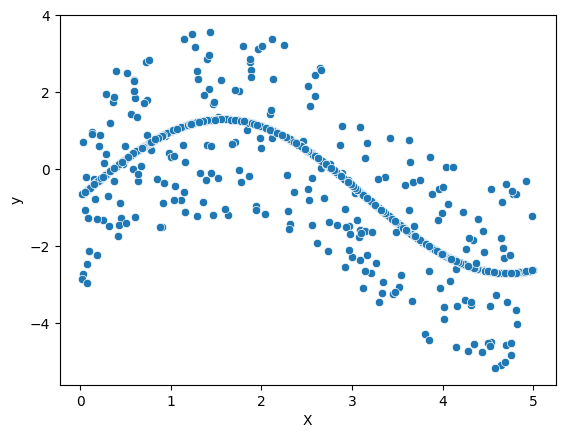

In [5]:
sns.scatterplot(dd, x = dd["X"], y = dd["y"])

In [6]:
from sklearn.neighbors import KernelDensity
kd = KernelDensity(kernel = "gaussian", bandwidth = 0.5).fit(dd)

In [7]:
kd_score = kd.score_samples(dd)

In [64]:
soglia = np.quantile(kd_score, 0.2)
inl = kd_score > soglia
out = kd_score < soglia

In [9]:
out.sum()

np.int64(200)

<Axes: xlabel='X', ylabel='y'>

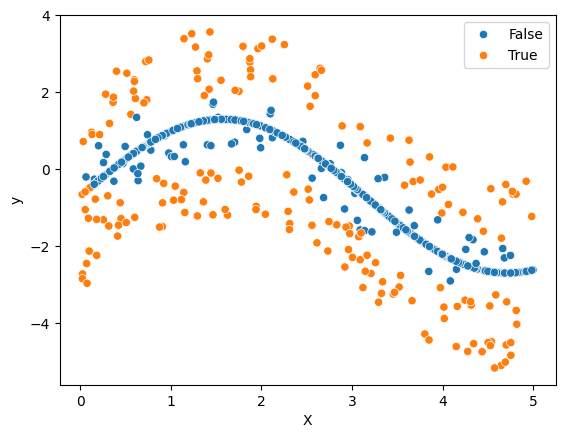

In [10]:
sns.scatterplot(dd, x = dd["X"], y = dd["y"], hue = out)

In [11]:
dd_clean = dd[inl]

## Regressione KernelRidge

In [12]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

In [13]:
X = dd_clean[["X"]]
y = dd_clean["y"]

In [14]:
X_train, X_te, y_train, y_te = train_test_split(X, y, random_state = 42, test_size = 0.05)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, random_state = 42, test_size=0.10)

In [15]:
sc = StandardScaler()
X_tr = sc.fit_transform(X_tr)
X_te = sc.transform(X_te)
X_val = sc.transform(X_val)

In [16]:
param_grid = {
    "alpha" : [0.01, 0.1, 1],
    "gamma" : [0.001, 0.01, 0.05]
}

In [17]:
kr = KernelRidge(kernel="rbf")
gs = GridSearchCV(kr, param_grid, cv = 5, n_jobs=4, scoring = "r2")
gs.fit(X_tr,y_tr)

GridSearchCV(cv=5, estimator=KernelRidge(kernel='rbf'), n_jobs=4,
             param_grid={'alpha': [0.01, 0.1, 1], 'gamma': [0.001, 0.01, 0.05]},
             scoring='r2')

In [18]:
mod = gs.best_estimator_
gs.best_params_

{'alpha': 0.01, 'gamma': 0.05}

In [19]:
gs.best_score_ # R2 sul train set

np.float64(0.9803020734303866)

In [20]:
y_pred = mod.predict(X_te)

In [21]:
from sklearn.metrics import r2_score
r2kern = r2_score(y_te, y_pred)
r2kern

0.9859444681942147

R2 su test set è 0.98. Il modello sembra avere una buona performance.

## Rete neurale densa

In [22]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from tqdm import trange
from inspect import signature


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ipyk

In [23]:
X_tr = X_tr.reset_index(drop = True)
X_te = X_te.reset_index(drop = True)
X_val = X_val.reset_index(drop = True)

y_tr = y_tr.reset_index(drop = True)
y_te = y_te.reset_index(drop = True)
y_val = y_val.reset_index(drop = True)

In [24]:
config = {
    "learning_rate": 1e-3,
    "batch_size": 64,
    "epochs": 20,
    "patience": 5,
    "min_delta": 0.01,
    "momentum": 0.9,
    "nesterov": True,
    "train_loss": nn.MSELoss(),
    "test_loss": nn.MSELoss(),
    "metrics": [r2_score, mean_squared_error, mean_absolute_error],
    "metric_average": None
}

In [25]:
device = "cpu"

In [26]:
class TensDataset(torch.utils.data.Dataset):
    def __init__(self, x_data, y_data):
        self.x = torch.tensor(x_data.values, dtype = torch.float32)
        self.y = torch.tensor(y_data.values, dtype = torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, index):
        return self.x[index], self.y[index]

In [27]:
train_data = TensDataset(X_tr, y_tr)
val_data = TensDataset(X_val, y_val)
test_data = TensDataset(X_te, y_te)

In [28]:
def make_dataloaders(train_data, val_data, test_data, 
                     batch=config["batch_size"], prefetch=None, no_pagemem=False):

    """costruisce i dataloaders di train, validazione e test a partire dai rispettivi dataset.

    Args:
        train_data (torch.utils.data.Dataset): data set di training
        val_data (torch.utils.data.Dataset): data set di validazione
        test_data (torch.utils.data.Dataset): data set di test
        batch (int, optional): dimenssione del batch. Defaults to config["batch_size"].
        prefetch (int, optional): n. di batch precaricati in ogni sottoprocesso. Defaults to 12.
        pagemem (bool, optional): uso della memoria non paginata per i tensori. Defaults to True.
    
    Returns:
        dataloaders (tuple[torch.utils.data.Dataloader, torch.utils.data.Dataloader, torch.utils.data.Dataloader]): una tupla contenente i tre dataloader
    """
    # Creiamo i data loaders che saranno gli iteraboili che generano i batch di
    # addestramento e/o test
    train_dataloader = DataLoader(train_data,
                                batch_size=batch,           # Imposta la dimensione del batch
                                shuffle=True,               # Shuffling dei batch tra un'epoca e l'altra
                                num_workers=0,              # Numero dei sottoprocessi di caricamento dei dati
                                prefetch_factor=prefetch,   # Batch precaricati da ogni sottoprocesso
                                pin_memory=no_pagemem)      # Usa la memoria non paginata per muovere i tensori
                                                            # da CPU a GPU
    val_dataloader = DataLoader(val_data,
                                batch_size=batch,
                                shuffle=True,
                                num_workers=0,
                                prefetch_factor=prefetch,
                                pin_memory=no_pagemem)

    test_dataloader = DataLoader(test_data,
                                batch_size=batch,
                                shuffle=True,
                                num_workers=0,
                                prefetch_factor=prefetch,
                                pin_memory=no_pagemem)

    # semplice investigazione della shape dei tensori: usiamo il primo
    # batch del test dataloader come esempio
    for X, y in test_dataloader:
        print(f"Shape e tipo dei campioni: {X.shape}, {X.dtype}")
        print(f"Shape e tipo delle etichette: {y.shape} {y.dtype}")
        break
    
    dataloaders = (train_dataloader, val_dataloader, test_dataloader)
    return dataloaders


In [29]:
train_loader, val_loader, test_loader = make_dataloaders(train_data,
                                                         val_data,
                                                         test_data, 
                                                         batch = config["batch_size"])

Shape e tipo dei campioni: torch.Size([40, 1]), torch.float32
Shape e tipo delle etichette: torch.Size([40]) torch.float32


In [30]:

class EarlyStopping:
    """Implementazione del Early Stopping
    
        Args:
            patience (int): numero epoche di pazienza
            min_delta (float): incremento minimo della loss di validazione 
    """
    def __init__(self, 
                 patience=config["patience"], 
                 min_delta=config["min_delta"]):

        self.patience = patience
        self.min_delta = min_delta              # valore minimo di decrescita della loss di validazione all'epoca corrente
                                                # per asserire che c'è un miglioramenti della loss
        self.counter = 0                        # contatore delle epoche di pazienza
        self.early_stop = False                 # flag di early stop
        self.min_validation_loss = torch.inf    # valore corrente ottimo della loss di validazione

    def __call__(self, validation_loss):
        """chiamata in forma funzionale dell'oggetto di classe EarlySopping

        Args:
            validation_loss (float): valore della loss di validazione
        """

        # chiamata in forma funzionale dell'oggetto di classe EarlySopping

        if (validation_loss + self.min_delta) >= self.min_validation_loss:  # la loss di validazione non decresce
            self.counter += 1                                               # incrementiamo il contatore delle epoche di pazienza
            if self.counter >= self.patience:
                self.early_stop = True
        else:                                                   # c'è un miglioramento della loss:
            self.min_validation_loss = validation_loss          # consideriamo la loss corrente
                                                                # come nuova loss ottimale
            self.counter = 0                                    # e azzeriamo il contatore di pazienza


def train_loop(model, 
               dataloader, 
               optimizer, 
               device, 
               pbar, 
               loss_fn=config["train_loss"]):
    """Ciclo di addestramento sui batch di un'epoca

    Args:
        model (torch.nn.Module): classe del modello neurale
        dataloader (torch.utils.data.Dataloader): dataloader di addestramento
        optimizer (torch.optim.Optimizer): ottimizzatore
        device (torch.device or int or str): device di esecuzione dell'addestramento
        pbar (tqdm): progress bar
        loss_fn (optional): loss di addestramento definita in ``torch.nn``. Defaults to config["train_loss"]

    Returns:
        float: loss media sui batch
    """

    num_batches = len(dataloader)
    epoch_loss = 0.0

    # Impostiamo la modalità di training del modello: è una best practice che serve per il
    # dropout e/o batch normalization
    model.train()
    for _, (X, y) in zip(pbar,dataloader):      # questa iterazione fatta così garantisce l'avanzamento della progress
                                                # bar mentre i batch vengono prelevati dal dataloader

        # Spostiamo esplicitamente i tensori sul device di computazione
        X, y = X.to(device), y.to(device)

        # Passo esplicito di addestramento
        optimizer.zero_grad()                   # azzeriamo i gradienti dell'iterata precedente

        # Calcoliamo la loss ed effettuiamo la predizione del minibatch
        logits = model(X)
        batch_loss = loss_fn(logits, y)

        epoch_loss += batch_loss.item()

        batch_loss.backward()             # step di backpropagation

        optimizer.step()                  # passo di ottimizzazione e aggiornamento dei parametri


    # Ritorniamo la loss media dell'epoca
    return epoch_loss/num_batches

In [31]:
def eval_loop(model, 
              dataloader, 
              device, 
              loss_fn=config["test_loss"], 
              metrics=config["metrics"],
              average=config["metric_average"]):
    """ciclo di test/validazione su un'epoca

    Args:
        model (torch.nn.Module): classe del modello neurale
        dataloader (torch.utils.data.Dataloader): dataloader di test/validazione
        device (torch.device or int or str): device di esecuzione dell'addestramento
        loss_fn (optional): loss di test/validazione definita in ``torch.nn``. Defaults to config["test_loss"]
        metrics (list[callable(y_true, y_pred, **kwargs)], optional): lista delle metriche definite dall'utente che possono o meno avere un parametro average per la gestione delle metriche multiclasse. Defaults to config["metrics"]
        average (string|None, optional): parametro di calcolo delle metriche medie multiclasse. Segue la convenzione di sklearn: {‘micro’, ‘macro’, ‘samples’, ‘weighted’, ‘binary’} or None. Defaluts to config["metric_average"]

    Returns:
        tuple[float, float, dict[]]: loss di test/validazione, accuracy, dizionario dei valori delle metriche definite nella configurazione e calcolate sull'epoca
    """

    # Impostiamo la modalità di valutazione del modello: è una best practice che serve per il
    # dropout e/o batch normalization
    model.eval()

    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss = 0.0

    y_true = []
    y_pred = []

    # context manager che disabilita esplicitamente il calcolo dei gradienti in fase di test
    with torch.no_grad():
        for X, y in dataloader:

            # Spostiamo esplicitamente i tensori sul device di computazione
            X, y = X.to(device), y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()

            # L'accuracy sul batch si calcola creando il tensore di dimensione pari al batch
            # per cui i massimi argomenti di ogni predizione sono uguali alla classe predetta
            # per il singolo campione, poi convertendo questo tensore di booleani in un vettore
            # binario di tipo float, sommando i valori 1 ed estraendo lo scalare contenuto nel tensore risultato
            # accuracy += (pred.argmax(1) == y).type(torch.float).sum().item()

            y_true.extend(y.cpu().detach().tolist())
            y_pred.extend(pred.cpu().detach().tolist())

    test_loss /= num_batches
    # accuracy /= size            # Per quanto detto prima, l'accuracy media va calcolata sulla dimensione del data set

    # Calcoliamo il dizionario delle metriche per epoca
    epoch_metrics = {}
    for metric in metrics:
        epoch_metrics[metric.__name__] = metric(y_true, y_pred)

    return test_loss, epoch_metrics, y_true, y_pred

In [32]:
def train_test(model,
               optimizer,
               device,
               train_dataloader,
               test_dataloader,
               epochs=config["epochs"],
               train_loss_fn=config["train_loss"],
               test_loss_fn=config["test_loss"],
               early_stopping=None,     # posso addestrare senza early stopping
               val_dataloader=None,     # e in questo caso non c'è validation set
               scheduler=None,          # possibile scheduler per monitorare l'andamento di un iperparametro, tipicamente il learning rate
               metrics=config["metrics"],
               average=config["metric_average"]):
    """Ciclo di addestramento completo con test, early stopping e scheduler del learning rate

    Args:
        model (torch.nn.Module): classe del modello neurale
        optimizer (torch.optim.Optimizer): ottimizzatore
        device (torch.device or int or str): device di esecuzione dell'addestramento/test
        train_dataloader (torch.utils.data.Dataloader): dataloader di addestramento
        test_dataloader (torch.utils.data.Dataloader): dataloader di test
        epochs (int): numero di epoche. Defaults to config["epochs"]
        train_loss_fn (optional): loss di addestramento definita in ``torch.nn``. Defaults to config["train_loss"]
        test_loss_fn (optional): loss di test/validazione definita in ``torch.nn``. Defaults to config["test_loss"]
        early_stopping (EarlyStopping, optional): classe di early stopping se presente. Defaults to None.
        metrics (list[callable(y_true, y_pred, **kwargs)], optional): lista delle metriche definite dall'utente che possono o meno avere un parametro average per la gestione delle metriche multiclasse. Defaults to config["metrics"]
        average (string|None, optional): parametro di calcolo delle metriche medie multiclasse. Segue la convenzione di sklearn: {‘micro’, ‘macro’, ‘samples’, ‘weighted’, ‘binary’} or None. Defaluts to config["metric_average"]

    Returns:
        tuple[float, float, float, list[float], dict[list[float]]]: valori delle loss di train, test e validazione, lista dei valori di accuracy per epoca, dizionario con le liste dei valori delle metriche per epoca
    """
                                    

    # liste dei valori di loss e accuracy epoca per epoca per il plot
    train_loss, validation_loss, test_loss = [], [], []
    #accuracy = []
    best_val_mse = float("inf")
    
    # dizionario delle liste dei valori delle metriche di test epoca per epoca
    test_metrics = {}   
    for metric in metrics:
        test_metrics[metric.__name__] = []

    num_batches = len(train_dataloader.batch_sampler) # il campionatore dei batch del dataloader ha il protocollo 
                                                      # __len__ e può fornirci il numero dei batch campionabili

    # Ciclo di addestramento con early stopping
    for epoch in range(1,epochs+1):

        # Progress bar
        pbar = trange(num_batches)
        pbar.set_description(desc='Epoch {:4d}'.format(epoch))

        epoch_train_loss = train_loop(model, train_dataloader, optimizer, device, pbar, loss_fn=train_loss_fn)
        train_loss.append(epoch_train_loss)

        # validation se è presente val_dataloader
        if val_dataloader != None:
                epoch_validate_loss, epoch_validate_metrics , *_ = eval_loop(model, val_dataloader, device, loss_fn=test_loss_fn, metrics=metrics)
                validation_loss.append(epoch_validate_loss)

        # test 
        epoch_test_loss, epoch_metrics, *_ = eval_loop(model, test_dataloader, device, loss_fn=test_loss_fn, metrics=metrics)

        test_loss.append(epoch_test_loss)
        # accuracy.append(epoch_accuracy)
        for metric in metrics:
            test_metrics[metric.__name__].append(epoch_metrics[metric.__name__])


        val_str = f'Validation loss: {epoch_validate_loss:6.4f}\n' if val_dataloader != None else ' '

        print(f"Train loss: {epoch_train_loss:6.4f}\n{val_str}Test loss: {epoch_test_loss:6.4f}")
        
        for label, metric in epoch_metrics.items():     
              print(f'{label}: {metric:6.2f} ', end=' ')
        
        print()

        # early stopping
        if early_stopping != None:
            if epoch_validate_metrics["mean_squared_error"] < best_val_mse:
                 best_val_mse = epoch_validate_metrics["mean_squared_error"]
                 save_model(model, optimizer, epoch, train_loss, validation_loss, test_loss, test_metrics, path=f"best_mod_{epoch}.pth")
            early_stopping(epoch_validate_loss)
            if early_stopping.early_stop:
                break

        # scheduler dell'iperparametro
        if scheduler != None:
            scheduler.step()

    return train_loss, validation_loss, test_loss, test_metrics

def save_model(net, optimizer, current_epoch, train_loss, val_loss, test_loss, metrics, path):
    """Salvataggio del modello con tutte le informazioni di stato e le metriche in un file pickle

    Args:
        net (torch.nn.Module): classe del modello neurale
        optimizer (torch.optim.Optimizer): ottimizzatore
        current_epoch (int): numero di epoche di addestramento
        train_loss (list[float]): lista dei valori della loss di addestramento
        val_loss (list[float]): lista dei valori della loss di validazione
        test_loss (list[float]): lista dei valori della loss di test
        accuracy (list[float]): lista dei valori dell'accuracy
        metrics (dict[list[float]]): liste dei valori delle metriche definite dall'utente
        path (os.path): percorso completo del file di salvataggio
    """

    # Abbiamo deciso per queste informazioni, ma possiamo caricare qualunque cosa
    to_save = {
            'epoch': current_epoch,
            'model_state_dict': net.state_dict(),               # configurazione di tutti i layer *addestrabili* del modello
            'optimizer_state_dict': optimizer.state_dict(),     # configurazione e operparametri dell'ottimizzatore
            'training_loss': train_loss,
            'validation_loss': val_loss,
            'test_loss': test_loss
            #'accuracy': accuracy
    }
    
    to_save.update(metrics)
    
    torch.save(to_save, path)


def load_model(path, model, optimizer, device = None):
    """  Ricarichiamo il dizionario e restituiamo la tupla delle informazioni. La rete e l'ottimizzatore devono essere inizializzati prima chiamare la funzione

    Args:
        path (os.path): percorso completo del file del modello
        model (torch.nn.Module): modello inizializzato
        optimizer (torch.optim.Optimizer): ottimizzatore inizializzato
        device (torch.device or int or str): device di caricamento del modello. Defaults to None.

    Returns:
        tuple[torch.nn.Module, torch.optim.Optimizer, Any]: tupla contenente il modello, l'ottimizzatore e tutto lo stato conservato da ``save_model()``
    """


    # Se il device è specificato e non è la CPU, allora muoviamo il modello sul device
    if device != None and device != 'cpu':
        model.to(device)

    # carichiamo il model checkpoint
    checkpoint = torch.load(path)

    # inizializziamo lo stato del modello e dell'ottimizzatore
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # restituiamo tutte le informazioni in una tupla
    return (model,
            optimizer,
            checkpoint
            )

In [33]:
class ReteDensa(nn.Module):
    def __init__(self, input_dim):
        super(ReteDensa, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        return self.network(x).squeeze(1)

In [34]:
input_dim = X_tr.shape[1]
input_dim

1

In [35]:
from torchinfo import summary
model = ReteDensa(input_dim)
summary(model)

Layer (type:depth-idx)                   Param #
ReteDensa                                --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       256
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       8,256
│    └─ReLU: 2-4                         --
│    └─Dropout: 2-5                      --
│    └─Linear: 2-6                       2,080
│    └─ReLU: 2-7                         --
│    └─Dropout: 2-8                      --
│    └─Linear: 2-9                       528
│    └─ReLU: 2-10                        --
│    └─Dropout: 2-11                     --
│    └─Linear: 2-12                      17
Total params: 11,137
Trainable params: 11,137
Non-trainable params: 0

In [36]:
es = EarlyStopping()
from torch.optim import Adam 
opt = Adam(model.parameters(), lr = config["learning_rate"], betas = [0.92, 0.997])

In [37]:
train_loss, validation_loss, test_loss, test_metrics = train_test(
    model = model,
    optimizer = opt,
    device = device, 
    train_dataloader = train_loader,
    test_dataloader = test_loader,
    val_dataloader= val_loader,
    early_stopping = es
)

Epoch    1: 100%|██████████| 11/11 [00:00<00:00, 13.61it/s]


Train loss: 2.1853
Validation loss: 1.4132
Test loss: 1.5164
r2_score:   0.02  mean_squared_error:   1.52  mean_absolute_error:   0.92  


Epoch    2: 100%|██████████| 11/11 [00:00<00:00, 22.55it/s]


Train loss: 1.8090
Validation loss: 1.6061
Test loss: 1.1637
r2_score:   0.25  mean_squared_error:   1.16  mean_absolute_error:   0.81  


Epoch    3: 100%|██████████| 11/11 [00:00<00:00, 28.02it/s]


...

Train loss: 0.2525
Validation loss: 0.0719
Test loss: 0.0453
r2_score:   0.97  mean_squared_error:   0.05  mean_absolute_error:   0.17  


Epoch   14: 100%|██████████| 11/11 [00:00<00:00, 45.24it/s]


Train loss: 0.2509
Validation loss: 0.0437
Test loss: 0.0381
r2_score:   0.98  mean_squared_error:   0.04  mean_absolute_error:   0.15  


Epoch   15: 100%|██████████| 11/11 [00:00<00:00, 26.19it/s]


Train loss: 0.2520
Validation loss: 0.0346
Test loss: 0.0292
r2_score:   0.98  mean_squared_error:   0.03  mean_absolute_error:   0.14  


In [41]:
def displayLosses(train_loss, test_loss, validation_loss):
    """plot dell'andamento delle loss di addestramento/validazione/test lungo le epoche di addestramento

    Args:
        train_loss (list[float]): loss di addestramento
        test_loss (list[float]): loss di test
        validation_loss (list[float]): loss di validazione
    """
        
    epochs = range(1, len(train_loss)+1) # calcolo del range delle epoche
    
    plt.plot(epochs, train_loss, label='training loss')
    plt.plot(epochs,validation_loss, label='validation loss')
    plt.plot(epochs, test_loss, label='test loss')
    plt.legend(loc='lower right')
    plt.title("Loss di addestramento")
    # plt.ylim(0,1)
    plt.show()
    

def displayMetrics(metrics):
    """plot dell'andamento dell'accuracy di addestramento e delle metriche di test lungo le epoche di addestramento

    Args:
        accuracy (list[float]): accuracy di addestramento
        metrics (tuple[list[float]]): dizionario delle metriche di test
    """
    epochs = range(1, 16) # calcolo del range delle epoche
    
    # plt.plot(epochs, accurac, label="train acc.")
    
    for label, metric in metrics.items():
        plt.plot(epochs, metric, label=label)
    
    plt.legend(loc='lower right')
    plt.title("Metriche")
    # plt.ylim(0,1)
    plt.show()


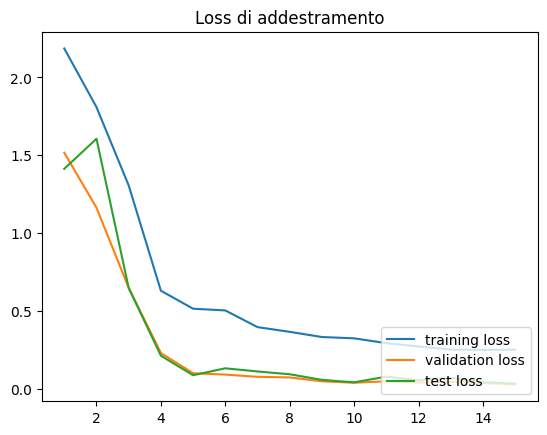

In [42]:
displayLosses(train_loss, validation_loss, test_loss)

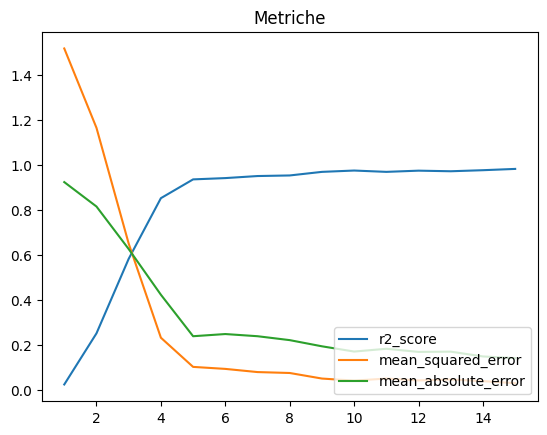

In [43]:
displayMetrics(metrics = test_metrics)

In [44]:
model, optimizer, checkpoint = load_model("best_mod_15.pth", model, opt, device)

In [45]:
r2kern

0.9859444681942147

In [46]:
test_loss, epoch_metrics, y_true_nn, y_pred_nn = eval_loop(model, test_loader, device)

In [47]:
r2nn = r2_score(y_true_nn, y_pred_nn)

In [48]:
r2nn

0.9812220510168497

Il modello kernelridge performa leggermente meglio, ma in generale i due modelli sembrano essere ottimi.

In [49]:
X_pool = np.array(X_te)

In [50]:
minimo = np.min(X_pool)

In [51]:
massimo = np.max(X_pool)

In [52]:
X_fittizio = pd.DataFrame(np.random.uniform(minimo, massimo, 1000), columns = ["X"])

In [53]:
y_new = mod.predict(X_fittizio)

In [54]:
X_fittizio

,X
0,-1.487796
1,-0.779697
2,0.585683
3,-0.828222
4,-0.364615
...,...
995,-0.069602
996,0.646612
997,-0.450374
998,0.922022


In [55]:
dd = pd.DataFrame(data = {
    "X_new": X_fittizio['X'],
    "y_new": y_new
})

In [56]:
dd

,X_new,y_new
0,-1.487796,0.228256
1,-0.779697,1.224461
2,0.585683,-1.055125
3,-0.828222,1.217781
4,-0.364615,0.957001
...,...,...
995,-0.069602,0.473310
996,0.646612,-1.204179
997,-0.450374,1.056303
998,0.922022,-1.839849


<Axes: xlabel='X_new', ylabel='y_new'>

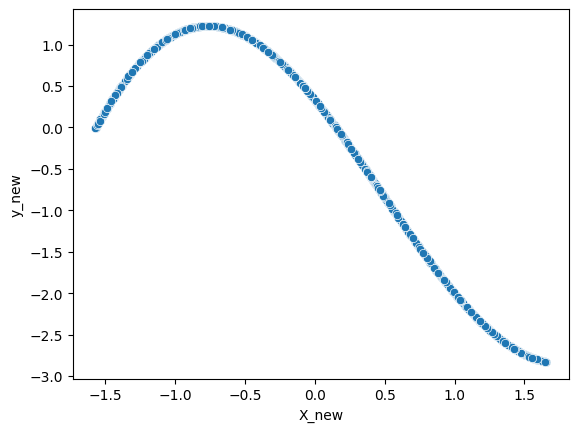

In [58]:
sns.scatterplot(dd, x = dd["X_new"], y = dd["y_new"])

In [59]:
X_new = dd["X_new"]
y_new = dd["y_new"]

In [60]:
X_new = X_new.reset_index(drop=True)
y_new = y_new.reset_index(drop=True)



In [61]:
new_data = TensDataset(X_new, y_new)

In [62]:
# 3. Predict con la rete neurale (senza eval_loop)
model.eval()
X_tensor = torch.tensor(X_fittizio.values, dtype=torch.float32)
with torch.no_grad():
    y_nn = model(X_tensor).tolist()

<Axes: xlabel='X', ylabel='y_kernelridge'>

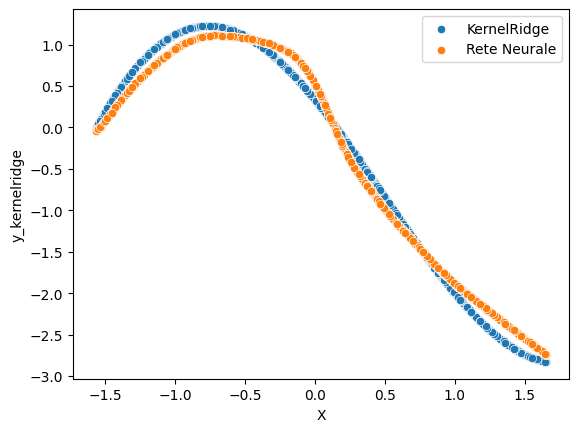

In [63]:
# 4. Confronto
dd_new = pd.DataFrame({
    "X": X_fittizio["X"],
    "y_kernelridge": y_new,
    "y_rete": y_nn
})

# 5. Plot
sns.scatterplot(dd_new, x="X", y="y_kernelridge", label="KernelRidge")
sns.scatterplot(dd_new, x="X", y="y_rete", label="Rete Neurale")